# Apertures in dLux

dLux provides a number of built in apertures, as well as a number of powerful tools to create custom and differentiable apertures. This tutorial will go over how to create a number of different common aperture types, the basic API, and how to create both custom and dynamic (i.e. differentiable) apertures. It is broken up into the following sections:

1. Pre-Built Apertures
2. Custom Apertures
3. Dynamic Apertures

In [ ]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import equinox as eqx
from jax import jit, vmap

# dLux imports
import dLux.utils as dlu

# Visualisation imports
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 90

---

## 1. Pre-Built Apertures

**Standard Aperture**

dLux provides a handful of pre-built aperture types that can be used to easily generate common aperture types. The three core pre-built aperture types are:
- `circular_aperture`: A simple circular aperture with a primary-secondary configuration and azimuthally symmetric spiders. This is a very common aperture type, and it used for example in the Hubble space telescope, the Subaru telescope, and the VLT telescopes.
- `segmented_aperture`: A segmented hexagonal aperture with a primary-secondary configuration and azimuthally symmetric spiders. This is also a very common aperture type, and it is used for example in the James Webb space telescope and the Keck telescopes.
- `sparse_aperture`: A sparse aperture with a user defined number of circular or hexagonal sub-apertures, each with their own position and radius. These apertures are commonly found in interferometers, and they are used for example in the CHARA array and the VLTI, or in Specialised observing modes such as AMI on JWST.

**Notable Aperture**

dLux also provides some functions to generate specific telescope apertures, which are _mostly_ just wrappers around these core aperture generating functions but sometimes with custom spiders. We current have thr following telescope apertures implemented:
- `hst_aperture`: This is just a thin wapper around `circular_aperture` with the correct parameters to generate the Hubble space telescope aperture.
- `jwst_aperture`: This is just a thin wrapper around `segmented_aperture` with the correct parameters to generate the James Webb space telescope aperture.
- `euclid_aperture`: This is a wrapper around `circular_aperture` with a custom implementation of the spiders, given that they are offset from the center of the aperture.

We are always open to adding more pre-built apertures, so if there is a specific aperture you would like to see added please feel free to open an issue or submit a PR!

**Aperture Aberrations**

These functions all also provide the option to generate a set of Zernike polynomials over each aperture, enabling the simple modelling of more realistic PSFs. These all share a unified API, as we will see.

### Circular Aperture/HST-like Aperture

Lets start with the hst_like aperture, since it is a simple wrapper around the `circular_aperture` function. We wil show how we can tweak the the parameters to generate a slightly different HST-like aperture, as well as some Zernike polynomials. Note that most of the parameters we are specifying here are just the default parameters for the `hst_aperture` function, so if you want to generate a standard HST-like aperture you can just call that function with just the npixels parameter.

In [2]:
# Angles of the spiders in degrees
angles = np.linspace(0, 360, 5, endpoint=False)

# Zernike noll indices to include in the basis
js = np.arange(2, 5)
z_names = [dlu.zernike_name(j) for j in js]

# Generate the aperture and the Zernike basis functions
aperture, basis = dlu.hst_like(
    npixels=512, # Number of pixels across the aperture
    diameter=2.4, # Diameter of the primary mirror in meters
    oversample=5, # Oversampling factor for the aperture (i.e. how many pixels across the aperture diameter)
    secondary_diameter=0.5, # Diameter of the secondary mirror in meters
    spider_width=0.05, # Width of the spiders in meters
    spider_angles=angles, # Angles of the spiders in degrees
    zernike_nolls=js, # Zernike noll indices to include in the basis
)

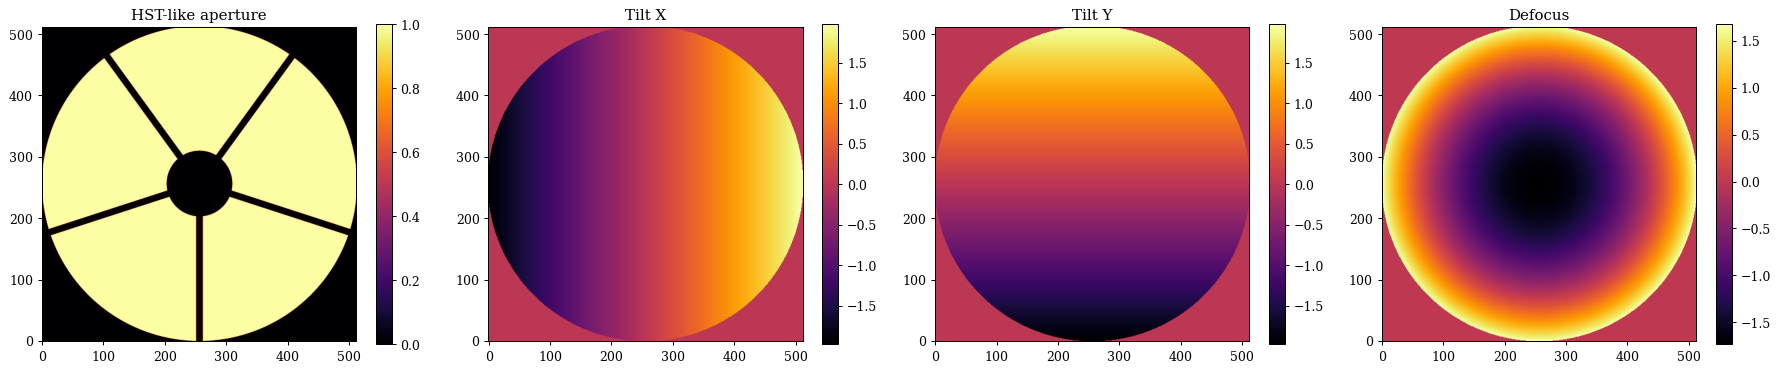

In [3]:
## COLLAPSE: Plotting
# Plot the aperture and the Zernike basis functions
plt.figure(figsize=(20, 4))
plt.subplot(1, 4, 1)
plt.title("HST-like aperture")
plt.imshow(aperture)
plt.colorbar()

for i in range(basis.shape[0]):
    plt.subplot(1, 4, i + 2)
    plt.title(z_names[i])
    plt.imshow(basis[i])
    plt.colorbar()
plt.tight_layout()
plt.show()

### Segmented Aperture/JWST-like Aperture

Now lets have a look at the segmented aperture, which is a bit more complex, and has a few more parameters to play with. We will show how we can tweak the parameters to generate a slightly different JWST-like aperture, as well as some Zernike polynomials. This function is also mostly using the default parameters for the `jwst_aperture` function so you can see what the inputs are.

In [4]:
# Custom spider angles for the JWST-like aperture
angles = 30 + np.linspace(0, 360, 6, endpoint=False)

# Generate the JWST-like aperture and the Zernike basis functions
aperture, basis = dlu.jwst_like(
    npixels=512, # Number of pixels across the aperture
    diameter=6.6, # Diameter of the primary mirror in meters
    nrings=3, # Number of rings of segments in the primary mirror
    oversample=5, # Oversampling factor for the aperture (i.e. how many pixels across the aperture diameter)
    gap=0.007, # Gap between the segments in meters
    segment_diameter=1.524, # Diameter of the segments in meters
    nrings_excluded=1, # Number of rings of segments to exclude from the aperture (i.e. to make holes in the aperture)
    spider_width=0.1, # Width of the spiders in meters
    spider_angles=angles, # Angles of the spiders in degrees
    zernike_nolls=js, # Zernike noll indices to include in the basis
)

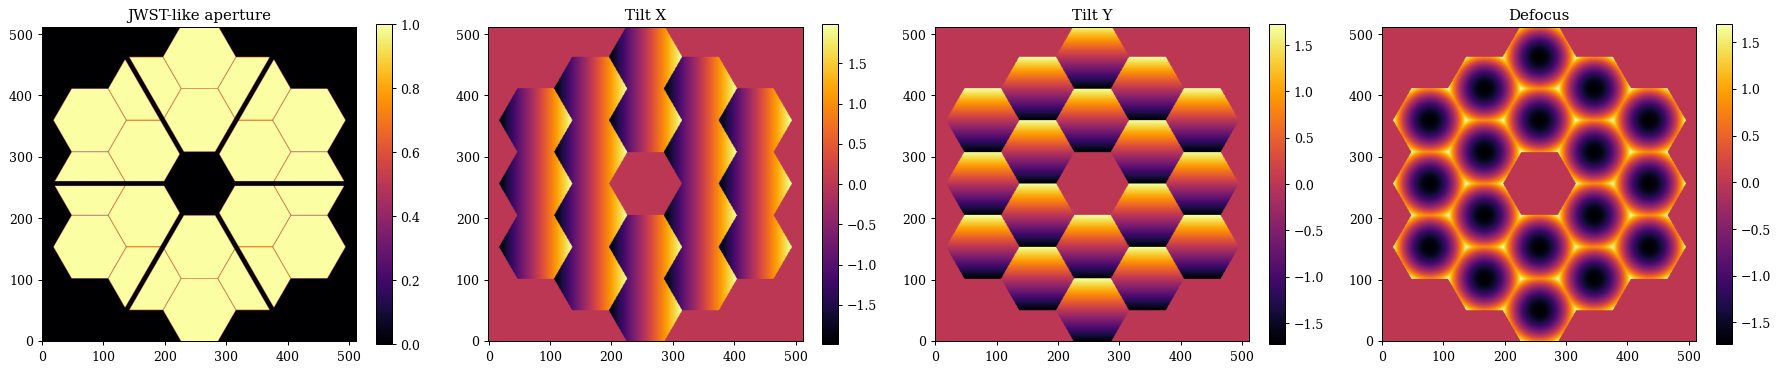

In [5]:
## COLLAPSE: Plotting
# Plot the aperture and the Zernike basis functions
plt.figure(figsize=(20, 4))
plt.subplot(1, 4, 1)
plt.title("JWST-like aperture")
plt.imshow(aperture)
plt.colorbar()

for i in range(basis.shape[1]):
    plt.subplot(1, 4, i + 2)
    plt.title(z_names[i])
    plt.imshow(basis.sum(0)[i])
    plt.colorbar()
plt.tight_layout()
plt.show()

### Segmented Aperture

Now lets have a look at the sparse aperture function, which enables us to create things like aperture masks or interferometric apertures. The main different here is that we need to specify the positions of each sub-aperture as well as their shape (either hexagonal: 'hex' or circular: 'circle'). All the rest of the API is functionally the same as the other aperture generating functions. Lets generate a an JWST AMI-like aperture, a simple 7-hole mask. 

In [6]:
# Generate some hole centers
inds = [7, 9, 10, 11, 13, 14, 18]
cens = dlu.segmented_hex_cens(3, 1.524 / 2)[inds, ...]

# Generate the aperture and basis
aperture, basis = dlu.sparse_aperture(
    npixels=512, # Number of pixels across the aperture
    diameter=6.6, # Diameter of the primary mirror in meters
    centers=cens, # Centers of the holes in meters
    hole_diameter=0.8, # Diameter of the holes in meters
    oversample=5, # Oversampling factor for the aperture (i.e. how many pixels across the aperture diameter)
    shape="hex", # Shape of the holes (either 'hex' or 'circle')
    zernike_nolls=js, # Zernike noll indices to include in the basis
)

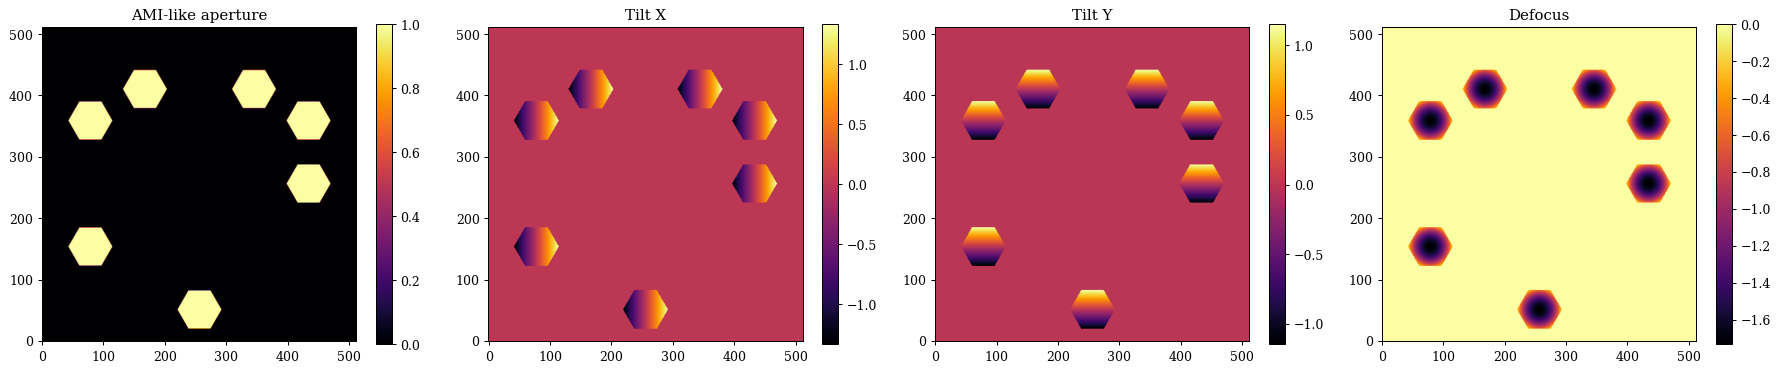

In [7]:
## COLLAPSE: Plotting
# Plot the aperture and the Zernike basis functions
plt.figure(figsize=(20, 4))
plt.subplot(1, 4, 1)
plt.title("AMI-like aperture")
plt.imshow(aperture)
plt.colorbar()

for i in range(basis.shape[1]):
    plt.subplot(1, 4, i + 2)
    plt.title(z_names[i])
    plt.imshow(basis.sum(0)[i])
    plt.colorbar()
plt.tight_layout()
plt.show()

## Euclid-like Aperture

Lets also take a quick-look at the Euclid-like aperture, which gives an idea of how we can create most telescope apertures with these classes plus some custom spiders. The Euclid aperture is also has some very nice asymmetric properties, which makes it a good aperture to use to test out phase-retrieval algorithms (like we do in some of the other tutorials). 

In [8]:
aperture, basis = dlu.euclid_like(
    npixels=512, # Number of pixels across the aperture
    diameter=1.21, # Diameter of the primary mirror in meters
    oversample=5, # Oversampling factor for the aperture (i.e. how many pixels across the aperture diameter)
    secondary_diameter=0.3, # Diameter of the secondary mirror in meters
    spider_width=0.075, # Width of the spiders in meters
    zernike_nolls=js, # Zernike noll indices to include in the basis
)

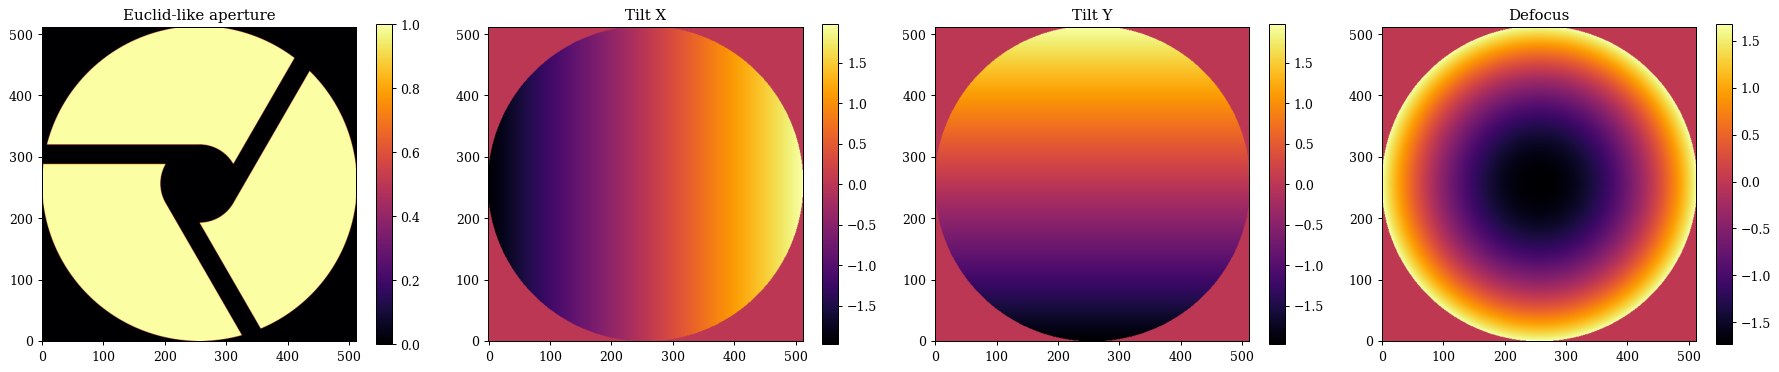

In [9]:
## COLLAPSE: Plotting
# Plot the aperture and the Zernike basis functions
plt.figure(figsize=(20, 4))
plt.subplot(1, 4, 1)
plt.title("Euclid-like aperture")
plt.imshow(aperture)
plt.colorbar()

for i in range(basis.shape[0]):
    plt.subplot(1, 4, i + 2)
    plt.title(z_names[i])
    plt.imshow(basis[i])
    plt.colorbar()
plt.tight_layout()
plt.show()

Okay awesome, as we can see its pretty easy to generate a lot of different aperture types with these functions, and to generate Zernike polynomials over each aperture to model aberrations. In the next section we will look at how to create custom apertures, which can be used to create more complex and unique aperture designs.

---

## 2. Custom Apertures

In many cases the pre-built apertures may not be sufficient to generate the specific aperture you want to model. dLux provides a wide range of low-level tools to create custom apertures (everything from above is done internally within dLux!). In order to get an idea of what these tools are and how to use them, we will go through the process of creating a custom aperture from scratch. We will first create a HST-like aperture and then create an AMI-like aperture. We will also show how these tools can be used to also generate the zernike basis functions over these custom apertures.

Most of the tools to create custom apertures are contained within the `dLux.utils.geometry` module, which provides a number of functions to create basic geometric shapes (circles, hexagons, rectangles, etc.) as well as functions to combine these shapes together to create more complex apertures. These functions are designed to work on the coordinates provides by the `dLux.utils.coordinates` module, which provides a number of functions to create coordinate grids and transform them in various ways. Finally, the code used to generate the Zernike polynomials is contained within the `dLux.utils.zernike` module, which provides a number of functions to generate Zernike polynomials over arbitrary apertures.


It is worth noting that the pre-built aperture functions can be used as a reference for how to use these low-level tools to create custom apertures, so don't be afraid to dive into the source code for these functions to see how they work and how they use the low-level tools to create the apertures.

**A custom HST-like Aperture**

Lets look at our HST-like aperture, except this time we are going to make the primary mirror an octagon and our secondary mirror a square.

In [10]:
# Start by generating a set of oversampled coordinates for the aperture
npixels = 512
diameter = 2.4
oversample = 5
coords = dlu.pixel_coords(npixels * oversample, diameter)

# Generate our primary mirror aperture with an octagonal shape
primary = dlu.reg_polygon(coords, diameter / 2, nsides=8)

# Generate our secondary mirror aperture with an inverted square
secondary_diameter = 0.5  # Diameter of the secondary mirror in meters
secondary = dlu.square(coords, secondary_diameter / 2, invert=True)

# Generate our spiders with the spiders function
spider_width = 0.05
spider_angles = angles = np.linspace(0, 360, 4, endpoint=False) + 45
spiders = dlu.spider(coords, spider_width, angles)

# Combine the primary, secondary, and spiders to get the full aperture
aperture = dlu.combine([primary, secondary, spiders], oversample)

Okay that was pretty simple, so what about the Zernike basis? The Zernike generation code has a very similar API to the aperture functions, so lets see how to make a Zernike basis for this aperture.

The main difference we want to consider here is that we aren't generating them on the oversampled basis, since there is not really a physical meaning to 'downsample' a Zernike, as the values at the edges of the aperture would no longer be correct. Instead we generate them on the same grid as the aperture itself, and use a slight oversize to ensure the basis functions span the full aperture!

In [11]:
# Generate the *non* oversampled coordinates
coords = dlu.pixel_coords(npixels, diameter)

# Generate the slightly oversized Zernike basis functions
basis = dlu.zernike_basis(js, coords, diameter=diameter * 1.01)

# Cut down the Zernikes to the primary mirror support
support = dlu.downsample(primary, oversample) > 0
basis = basis * support[None, ...]

Now we can plot and compare our custom aperture and Zernike basis functions, and see how they look!

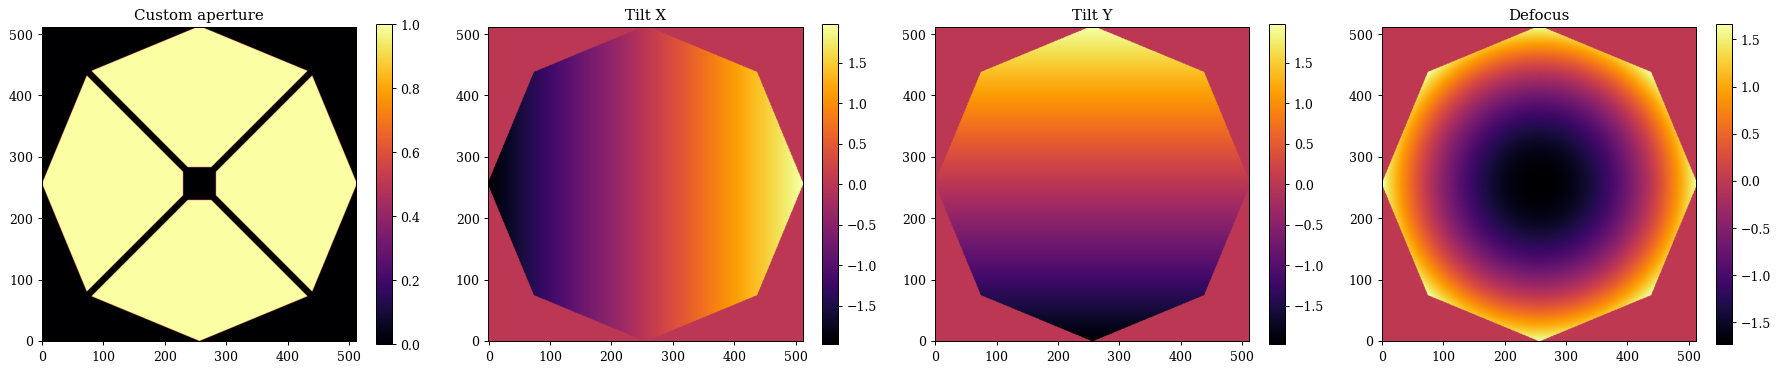

In [12]:
## COLLAPSE: Plotting
# Plot the aperture and the Zernike basis functions
plt.figure(figsize=(20, 4))
plt.subplot(1, 4, 1)
plt.title("Custom aperture")
plt.imshow(aperture)
plt.colorbar()

for i in range(basis.shape[0]):
    plt.subplot(1, 4, i + 2)
    plt.title(z_names[i])
    plt.imshow(basis[i])
    plt.colorbar()
plt.tight_layout()
plt.show()

**Double Slit Aperture**

Cool, so now what is we want to build a more abstract aperture, like the double slit experiment? This is also pretty simple to do with the low-level tools, we just need to create two rectangles and combine them together. Here is where we can see how to shift apertures around using the coordinates transformation functions. We will also see how we can combine _sparse_ apertures with the `combine` function `use_sum` option. We could also generate some Zernike polynomials over this aperture as well, but since this isn't usually part of the double-slit experiment, and our apertures will be very non-circular and therefore non-orthogonal, we wont generate them here, but the process would be the same as before.



In [13]:
# Start by generating a set of oversampled coordinates for the aperture
npixels = 512
diameter = 2
oversample = 5
coords = dlu.pixel_coords(npixels * oversample, diameter)

# Generate our two slits with the rectangle function
separation = 1
shift_fn = lambda x_pos: dlu.translate_coords(coords, np.array([x_pos, 0]))
slit1 = dlu.rectangle(shift_fn(separation/2), width=0.1, height=diameter / 2)
slit2 = dlu.rectangle(shift_fn(-separation/2), width=0.1, height=diameter / 2)
double_slit = dlu.combine([slit1, slit2], oversample, use_sum=True)

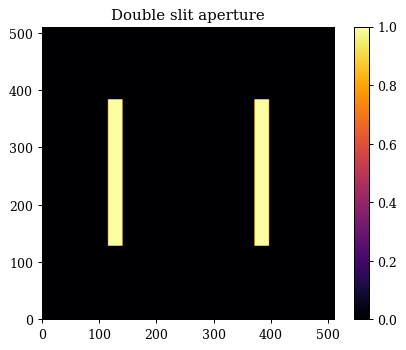

In [14]:
## COLLAPSE: Plotting
# Plot the double slit aperture
plt.figure(figsize=(5, 4))
plt.title("Double slit aperture")
plt.imshow(double_slit)
plt.colorbar()
plt.tight_layout()
plt.show()

---

## 3. Dynamic Apertures

Okay great, now that we have seen how we can create custom aperture, lets have a look at how we can make these apertures dynamic, or in other words, differentiable. This is a powerful feature of dLux that basically doesn't exist in any other optical simulation package. It opens a whole new set of optical calibration and design potential. It has already been used to recover both [physical and wavefront distortions to the aperture mask on JWST](https://arxiv.org/abs/2510.09806), as well as recovering the misalignment and drift of the HST NICMOS cold-mask pupil (paper in prep). It also opens the option to do things like end-to-end optimization of coronagraphs and other high-contrast imaging systems, which is something we are very excited about.

To aide in the recovery of _complex_ dynamic aperture shapes, dLux also provides the ability to provide polynomial distortions to coordinates systems - which is what we use to generate the apertures in the first place! This provides us with a high level of flexibility with a simple API. Lets use the same AMI mast as before, showing how we can create a differentiable version of the aperture!

These functions are also designed to be _fully compatible_ with jax, meaning we can jit, grad, vmap, etc. them to our hearts content! This means we can easily use these dynamic apertures in optimization and inference problems, which is super exciting!

In [15]:

# Generate some hole centers
inds = [7, 9, 10, 11, 13, 14, 18]
cens = dlu.segmented_hex_cens(3, 1.524 / 2)[inds, ...]

# Generating a set of non-oversampled coordinates for the aperture
npixels = 512
diameter = 6.6
coords = dlu.pixel_coords(npixels, diameter)

# Define the hexagon function
rmax = 0.8 / np.sqrt(3)
softness = 0.5 * diameter / npixels
hex_fn = lambda coords: dlu.soft_reg_polygon(coords, rmax, 6, clip_dist=softness)

# Coordinate distortion set up
powers = dlu.gen_powers(3) # Third order polynomial distortion
coeffs = np.zeros_like(powers) # Coefficients for the polynomial distortion

# Hole generation functions
distort_fn = lambda coeffs: dlu.distort_coords(coords, coeffs, powers)
coord_fn = lambda cen, coeffs: dlu.translate_coords(distort_fn(coeffs), cen)
hole_fn = lambda cen, coeffs: hex_fn(coord_fn(cen, coeffs))

# Now we can create the fast aperture generation function
aper_fn = jit(lambda coeffs, cen: vmap(hole_fn, in_axes=(0, None))(cen, coeffs).sum(0))

Awesome, now we have a fast, differentiable aperture generation function that we can use in a variety of applications! Lets try applying some random distortions and shifts to our aperture and see how it looks!

In [16]:
# Plain aperture
aperture = aper_fn(coeffs, cens)

# Distorted aperture
distortions = 0.02 * jr.normal(jr.key(0), shape=coeffs.shape)
distorted_aperture = aper_fn(coeffs + distortions, cens)

# Shifted aperture
shifts = 0.5 * jr.normal(jr.key(1), shape=cens.shape)
shifted_aperture = aper_fn(coeffs, cens + shifts)

# Shifted and distorted aperture
shifted_distorted_aperture = aper_fn(coeffs + distortions, cens + shifts)

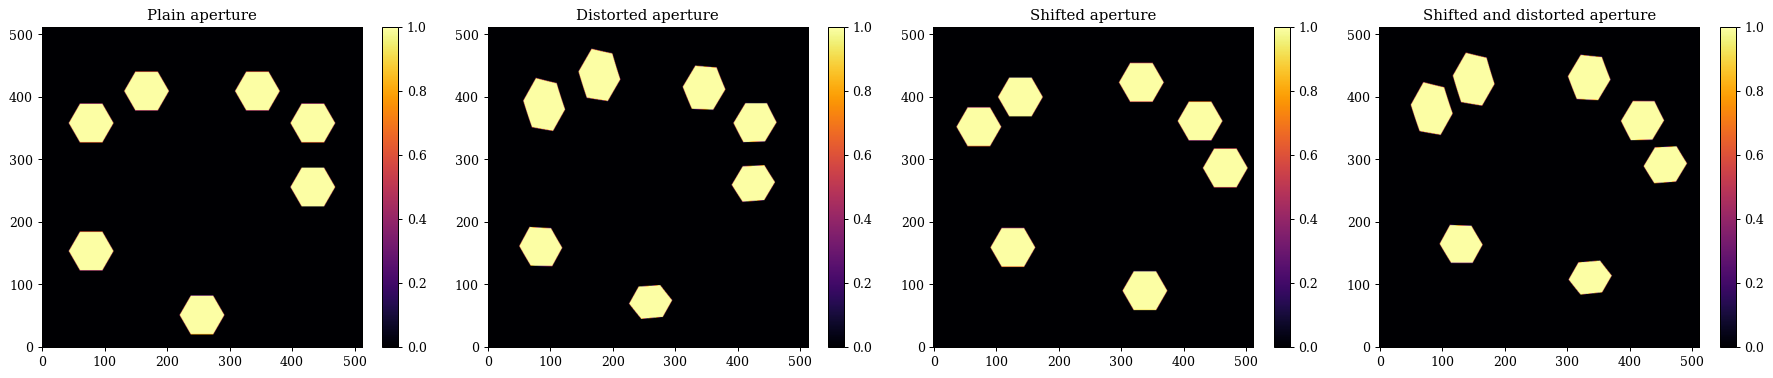

In [17]:
## COLLAPSE: Plotting
# Now lets have a look at them!
plt.figure(figsize=(20, 4))
plt.subplot(1, 4, 1)
plt.title("Plain aperture")
plt.imshow(aperture)
plt.colorbar()

plt.subplot(1, 4, 2)
plt.title("Distorted aperture")
plt.imshow(distorted_aperture)
plt.colorbar()

plt.subplot(1, 4, 3)
plt.title("Shifted aperture")
plt.imshow(shifted_aperture)
plt.colorbar()

plt.subplot(1, 4, 4)
plt.title("Shifted and distorted aperture")
plt.imshow(shifted_distorted_aperture)
plt.colorbar()

plt.tight_layout()
plt.show()

Pretty cool! Now lets check that our gradients are working correctly

In [18]:
# Define a simple loss function to check the gradients
def loss_fn(params, target):
    aperture = aper_fn(params["coeffs"], params["cens"])
    return np.mean((aperture - target) ** 2)

# Initialize the parameters at their distorted values
params = {
    "coeffs": coeffs + distortions,
    "cens": cens + shifts,
}

# Compute the loss and gradients and examine them
loss, grads = eqx.filter_value_and_grad(loss_fn)(params, aperture)

print("Loss:", loss)
print("Gradients for cens:", grads["cens"])
print("Gradients for coeffs:", grads["coeffs"])

Loss: 0.10399954
Gradients for cens: [[-0.03483739  0.01555587]
 [ 0.00139634  0.04428311]
 [ 0.01616716  0.00632419]
 [-0.00105111 -0.00074032]
 [-0.01101966  0.03689023]
 [-0.03352235  0.02372693]
 [ 0.01387123  0.02138328]]
Gradients for coeffs: [[ 4.8995782e-02 -3.6315620e-04  1.5526479e-01  8.1152119e-02
  -2.7263498e-02  2.5632763e-01]
 [-1.4742331e-01  1.3391176e-02 -2.6525241e-01 -5.1730144e-01
   4.3967422e-02 -4.8298120e-01]]


Awesome, now we have a dynamic version of our aperture! We can easily use this in optimization and inference problems, which is super exciting!

In practice, these dynamic aperture can be generated using the `dLux.layers.apertures` module, which provides a number of pre-built dynamic apertures, as well as the tools to create custom dynamic apertures. In some cases it is more practical to create a custom dynamic aperture using the low-level tools like shown here, and then to build a custom layer for this to reduce object clutter, but everything can be done with the existing infrastructure.

It's also worth noting that we can also dynamically and differentiably generate Zernike polynomials over these dynamic apertures with the same API as before, which opens up even more possibilities for calibration and design problems! The syntax is more-or-less the same, so we wont show that here as it would be a lot of just copy-pasting from the previous section, but feel free to try it out yourself!